In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from numpy import linalg as LA

edge_list_file_1 = "N200_y2.4_small_hubs.edgelist"
edge_list_file_2 = "N200_Erdos_Renyi_Graph_0.04.edgelist"

G1 = nx.read_edgelist(edge_list_file_1) # Reads a list of edges from the specified file and stores it as a graph object G1
G2 = nx.read_edgelist(edge_list_file_2)

deg1 = [d for _, d in G1.degree()]
deg_counts1 = np.bincount(deg1)
deg_unique1 = np.arange(len(deg_counts1))
nonzero1 = deg_counts1 > 0
probs1 = deg_counts1 / sum(deg_counts1) # Normalization: divide the total number of nodes

deg2 = [d for _, d in G2.degree()]
deg_counts2 = np.bincount(deg2)
deg_unique2 = np.arange(len(deg_counts2))
nonzero2 = deg_counts2 > 0
probs2 = deg_counts2 / sum(deg_counts2)

def remove_zero_y_values_np(x, y): # Remove points with zero values
    x = np.array(x)
    y = np.array(y)
    mask = y != 0
    return x[mask], y[mask]
d1, pr1 = remove_zero_y_values_np(deg_unique1, probs1)
d2, pr2 = remove_zero_y_values_np(deg_unique2, probs2)

# Graph visualization
def draw_graph(G, layout, node_color, edge_color='gray', scale=10, figsize=(12, 12)):
    layouts = {'spring': nx.spring_layout,'circular': nx.circular_layout,'kamada': nx.kamada_kawai_layout,'shell': nx.shell_layout}
    pos = layouts.get(layout, nx.spring_layout)(G)

    # The size of the nodes is proportional to the degree
    if isinstance(G, nx.DiGraph):
        degrees = dict(G.in_degree())
    else:
        degrees = dict(G.degree())
    node_sizes = [scale * degrees[n] for n in G.nodes()]
    plt.figure(figsize=figsize)
    nx.draw(G, pos, node_color=node_color, edge_color=edge_color, node_size=node_sizes)
    plt.show()

In [4]:
G = G1 # G1 G2 choose the graph
N=len(G) # Number of nodes
A = nx.adjacency_matrix(G) # Create an adjacency matrix of graph G. This is a matrix where each element A[i, j] is equal to 1 if there is an edge between nodes i and j, and 0 otherwise.
Matrix = [[0 for j in range(N)] for i in range(N)]

for i in range(N): # Copy elements from the adjacency matrix A to the matrix Matrix
    for j in range(N):
        Matrix[i][j] = A[i, j]

eg = LA.eigvals(Matrix) # Calculate the eigenvalues ​​of the matrix
k1p = 0
k1mean = []
for i in range(N): # Calculate the average degree for each node in the graph
    k1p = 0
    for j in range(N):
        k1p += A[i, j]
    k1mean.append(k1p)

# k1 - average node degree; k2 - mean square node degree
k2mean = [x**2 for x in k1mean]
k1 = sum(k1mean)/len(k1mean)
k2 = sum(k2mean)/len(k2mean)
zeta = k2/k1
maxk = max(k1mean)
mink = min(k1mean)

from scipy.optimize import fsolve
def f(x): # Function to find gamma for a given graph
    return mink * (x - 1)/(2 - x) * (N**((2 - x)/(x - 1))-1) - k1
root = fsolve(f, x0=2.1)
y = round(root[0], 2)
print('<k> -', round(k1, 1), '; ζ -', round(zeta, 1), '; kmax -', maxk, '; kmin -', mink, '; n -', y) # Calculated parameters of the scale-free graph

<k> - 7.8 ; ζ - 19.0 ; kmax - 71 ; kmin - 3 ; n - 2.46


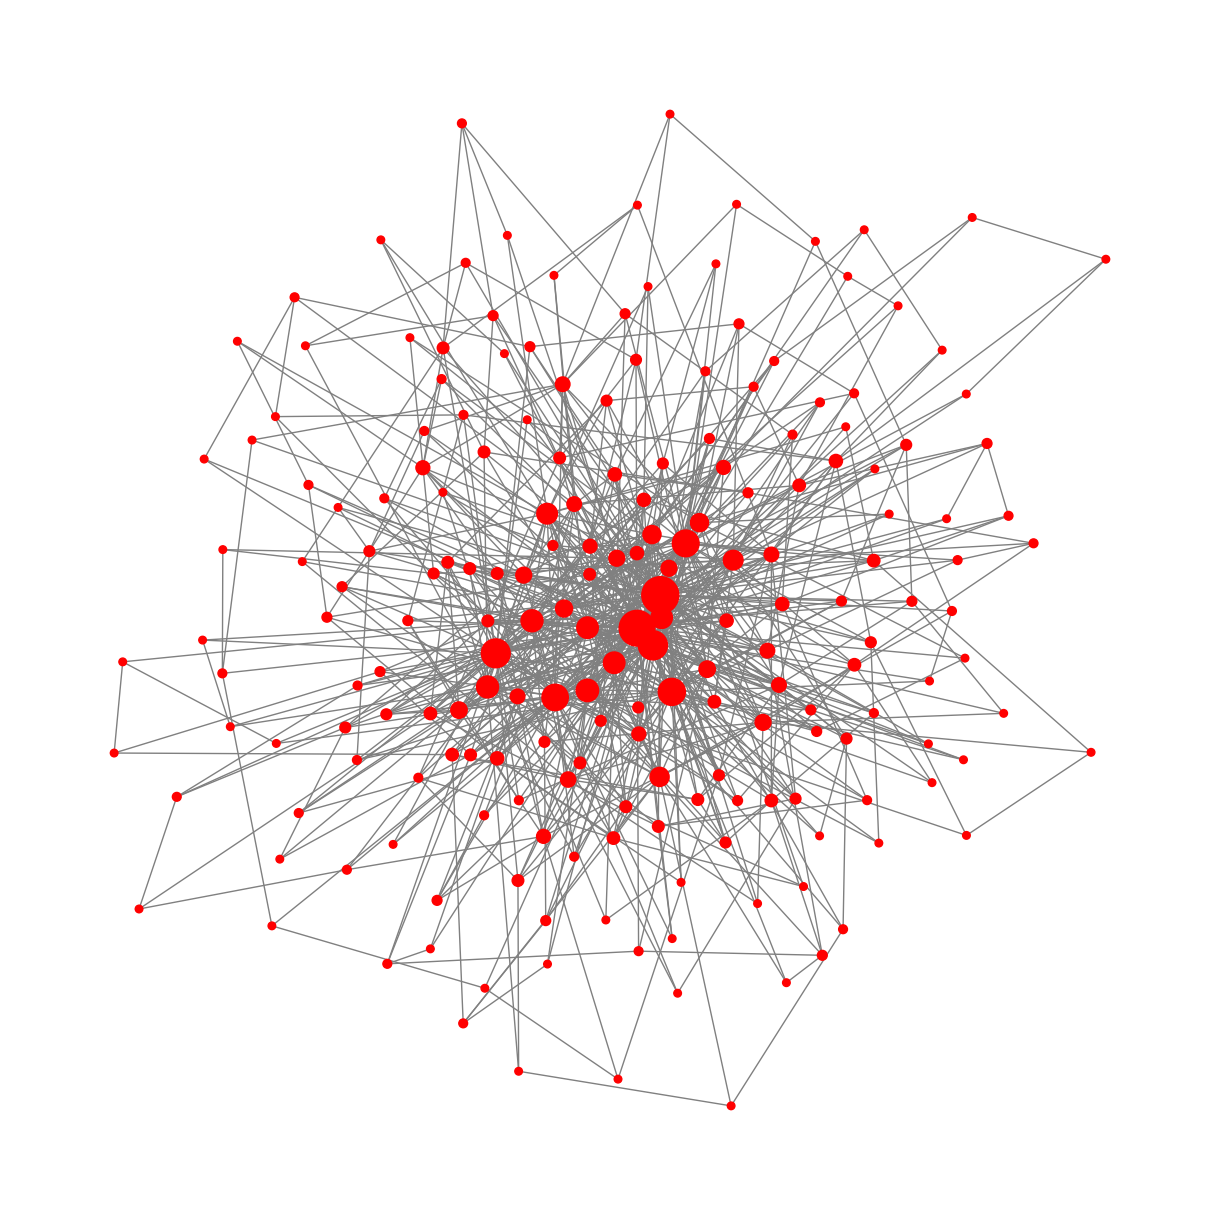

In [5]:
draw_graph(G1, layout='kamada_kawai_layout', node_color='red') # Visualization

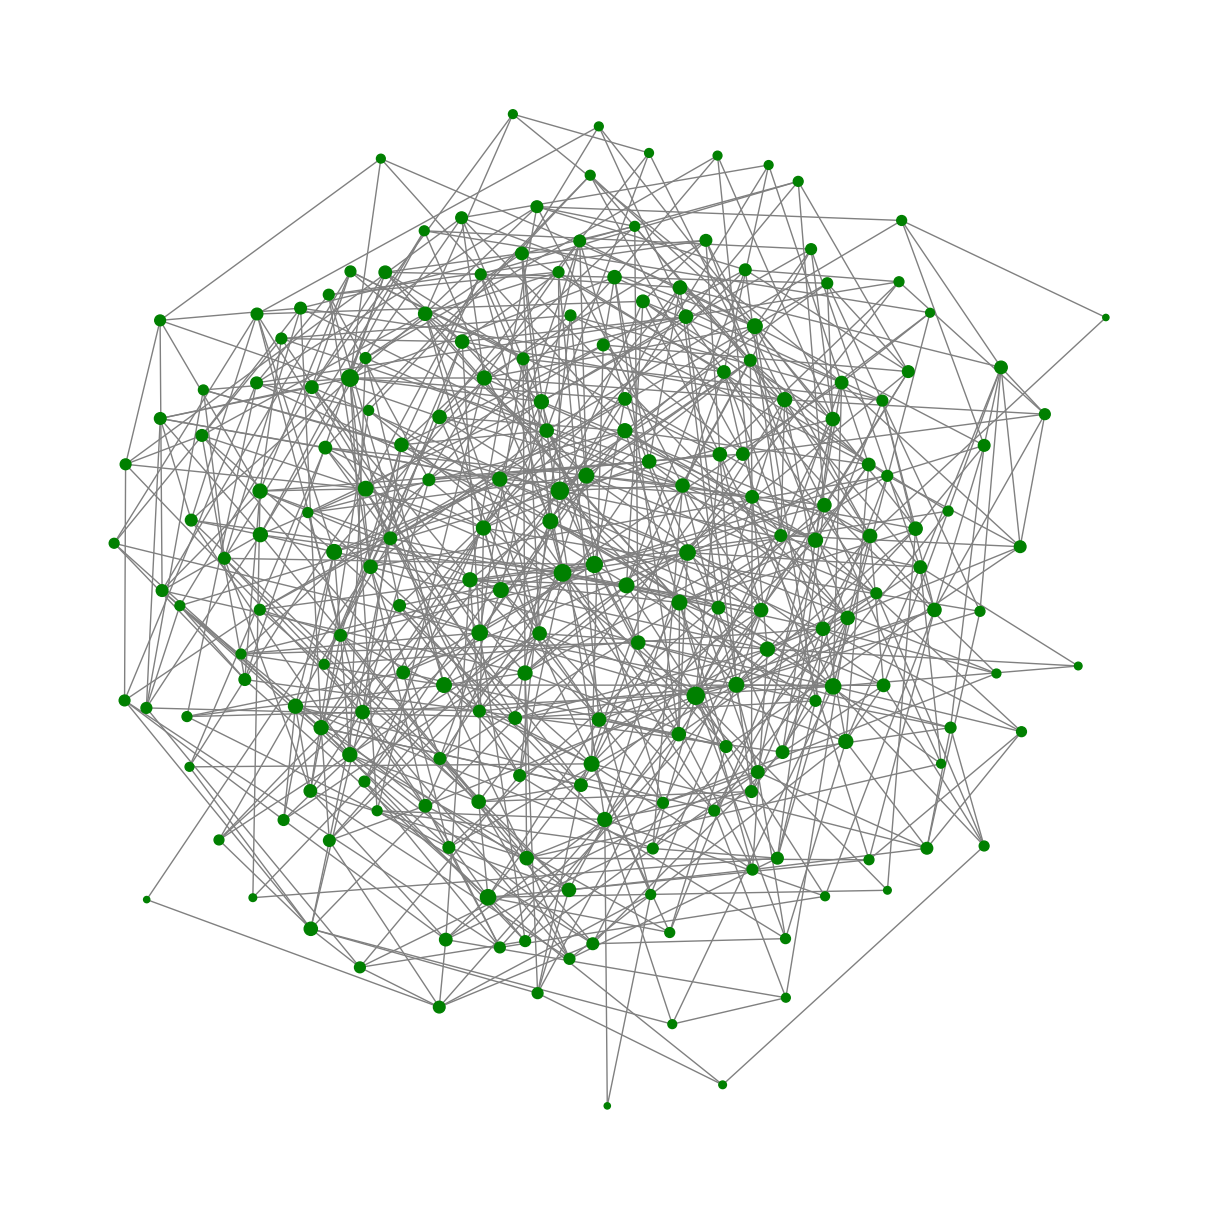

In [13]:
draw_graph(G2, layout='kamada', node_color='green')

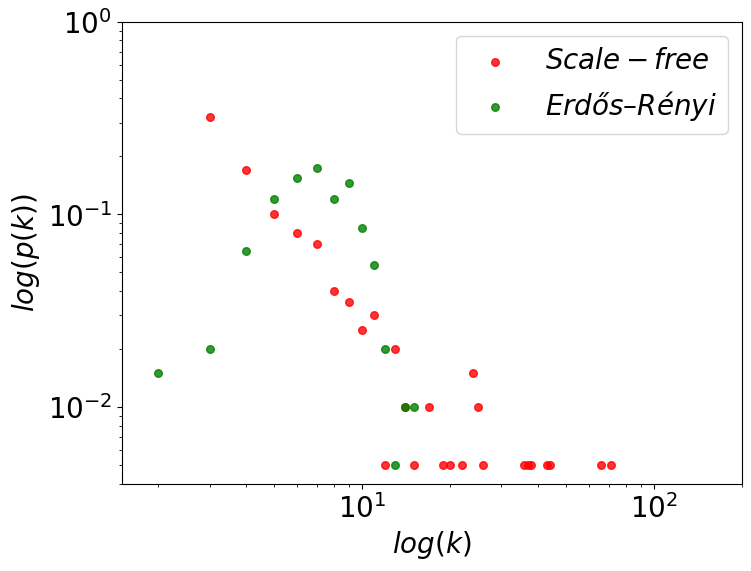

In [16]:
# log-log distribution
plt.figure(figsize=(8, 6))
plt.scatter(d1, pr1, s=30, color="red", alpha=0.8, label="$Scale-free$")
plt.scatter(d2, pr2, s=30, color="green", alpha=0.8, label="$Erdős–Rényi$")

plt.xscale("log")
plt.yscale("log")
plt.ylabel("$log(p(k))$", fontsize=20)
plt.xlabel("$log(k)$", fontsize=20)
plt.xlim(1.5, 200)
plt.ylim(0.004, 1)

plt.rc('font', weight='normal', size = 20)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.legend(loc='upper right', fontsize=20)
plt.show()